In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### API HOOKUP / DATA IMPORT

In [29]:
df_test = pd.read_csv('./data/predicting_f1_pit_stops/test.csv')
df = pd.read_csv('./data/predicting_f1_pit_stops/train.csv')
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


Column explanation:
- Driver – Driver code
- Compound_Encoded – Tire compound
- Year – Season of the race
- Race – Grand Prix name
- PitStop – Whether the driver pitted on that lap (0/1)
- LapNumber – Lap index within the race
- Stint – Tire stint number
- TyreLife – Number of laps on current tire
- Position – Driver's position on that lap
- LapTime (s) – Lap time in seconds
- LapTime_Delta – Change in lap time from previous lap
- Cumulative_Degradation – Accumulated tire performance drop
- RaceProgress – Fraction of race completed (0 → 1)
- Position_Change – Position gain/loss compared to previous lap

- Normalized_TyreLife (Not included) – Tire life normalized within stint

### DATA INSPECTION

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,439140.0,219569.500000,126768.942943,0.000000,109784.75000,219569.500000,329354.250000,439139.000
Year,439140.0,2023.523544,1.024930,2022.000000,2023.00000,2024.000000,2024.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.00000,0.000000,0.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.00000,2.000000,2.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,5.00000,10.000000,14.000000,20.000
LapTime (s),439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

In [28]:
print(f"Categorical columns: {df.select_dtypes(include='str').columns.tolist()}")
print(f"Numerical columns: {df.select_dtypes(exclude='str').columns.tolist()}")

Categorical columns: ['Driver', 'Compound', 'Race']
Numerical columns: ['id', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


In [33]:
# Clean column names
map_names = {
    "Driver": "driver",
    "Compound": "compound",
    "Race": "race",
    "Year": "year",
    "PitStop": "pit_stop",
    "LapNumber": "lap_number",
    "Stint": "stint",
    "TyreLife": "tyre_life",
    "Position": "position",
    "LapTime (s)": "lap_time_s",
    "LapTime_Delta": "lap_time_delta",
    "Cumulative_Degradation": "cumulative_degradation",
    "RaceProgress": "race_progress",
    "Position_Change": "position_change",
    "PitNextLap": "pit_next_lap",
}

df = df.rename(columns=map_names)
df_test = df_test.rename(columns=map_names)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   driver                  439140 non-null  str    
 2   compound                439140 non-null  str    
 3   race                    439140 non-null  str    
 4   year                    439140 non-null  int64  
 5   pit_stop                439140 non-null  int64  
 6   lap_number              439140 non-null  int64  
 7   stint                   439140 non-null  int64  
 8   tyre_life               439140 non-null  float64
 9   position                439140 non-null  int64  
 10  lap_time_s              439140 non-null  float64
 11  lap_time_delta          439140 non-null  float64
 12  cumulative_degradation  439140 non-null  float64
 13  race_progress           439140 non-null  float64
 14  position_change         439140 

### DATA WRANGLING

In [35]:
# Missing values
df.isnull().sum()

id                        0
driver                    0
compound                  0
race                      0
year                      0
pit_stop                  0
lap_number                0
stint                     0
tyre_life                 0
position                  0
lap_time_s                0
lap_time_delta            0
cumulative_degradation    0
race_progress             0
position_change           0
pit_next_lap              0
dtype: int64

In [38]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [144]:
duplicate_keys = ["driver", "race", "year", "lap_number"]
duplicates = df[df.duplicated(subset=duplicate_keys, keep=False)]
duplicates.sort_values(duplicate_keys)

,id,driver,compound,race,year,pit_stop,lap_number,stint,tyre_life,position,lap_time_s,lap_time_delta,cumulative_degradation,race_progress,position_change,pit_next_lap


### FEATURE EXPLORATION
#### TARGET VARIABLE INSPECTION

Target = 0 (80.1%), Target = 1 (19.9%)


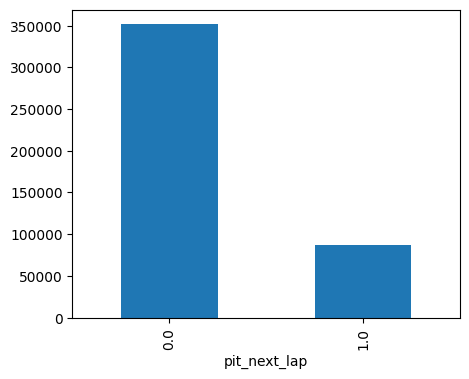

In [186]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
df.groupby('pit_next_lap').id.count().plot(kind='bar')
percent = (df.groupby('pit_next_lap').id.count() / df.shape[0]).tolist()
print(f"Target = 0 ({round(percent[0] * 100, 1)}%), Target = 1 ({round(percent[1] * 100, 1)}%)")


#### CATEGORICAL VARIABLES

In [68]:
print(df.select_dtypes(include='str').columns.tolist())

['driver', 'compound', 'race']


In [41]:
# Driver 
df.driver.nunique()

887

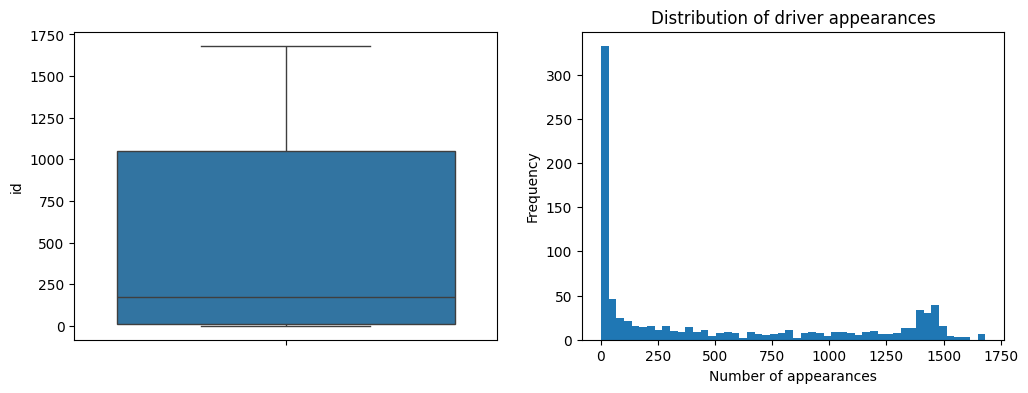

In [187]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(df.groupby('driver').id.count(), ax=ax[0])

df.groupby('driver').id.count().plot(kind='hist', bins=50, ax=ax[1])
ax[1].set_title('Distribution of driver appearances')
ax[1].set_xlabel('Number of appearances')
ax[1].set_ylabel('Frequency')

plt.show()

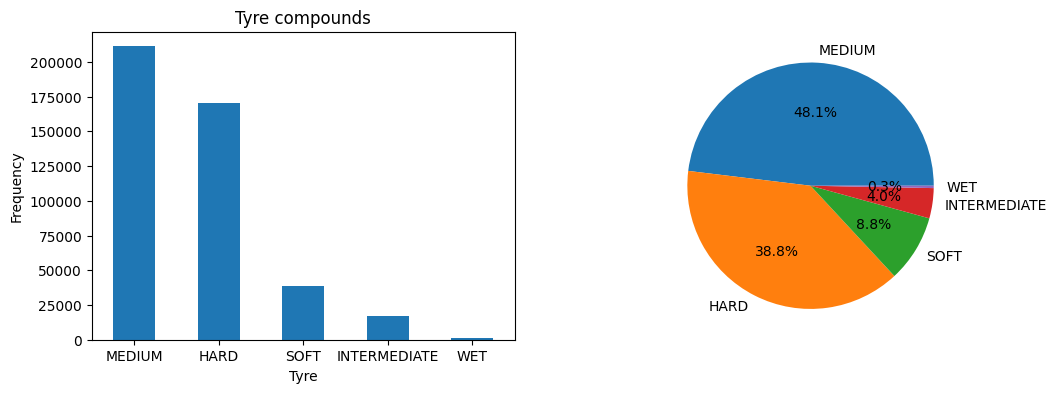

In [64]:
# Compound 
fig, ax = plt.subplots(1, 2, figsize=(12,4))
df.compound.value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title('Tyre compounds')
ax[0].set_xlabel('Tyre')
ax[0].set_ylabel('Frequency')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

df.compound.value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
plt.show()

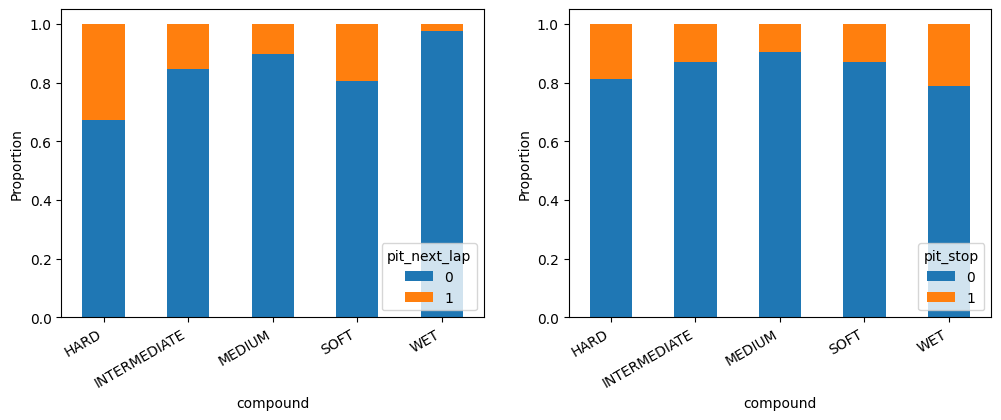

In [66]:
# Count 0s and 1s within each category
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts = (
    df.groupby(["compound", "pit_next_lap"])
    .size()
    .unstack(fill_value=0)
)
# Normalize within each group
normalized = counts.div(counts.sum(axis=1), axis=0)
# Plot normalized stacked bars
normalized.plot(kind="bar", stacked=True, ax=ax[0])
ax[0].set_xlabel("compound")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha='right')
ax[0].set_ylabel("Proportion")
ax[0].legend(title="pit_next_lap", labels=["0", "1"], loc='lower right')

counts_pit = (
    df.groupby(['compound', 'pit_stop'])
    .size()
    .unstack(fill_value=0)
)

# Normalize within each group
normalized_pit = counts_pit.div(counts_pit.sum(axis=1), axis=0)

# Plot normalized stacked bars
normalized_pit.plot(kind="bar", stacked=True, ax=ax[1])
ax[1].set_xlabel("compound")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=30, ha='right')
ax[1].set_ylabel("Proportion")
ax[1].legend(title="pit_stop", labels=["0", "1"], loc='lower right')

plt.show()

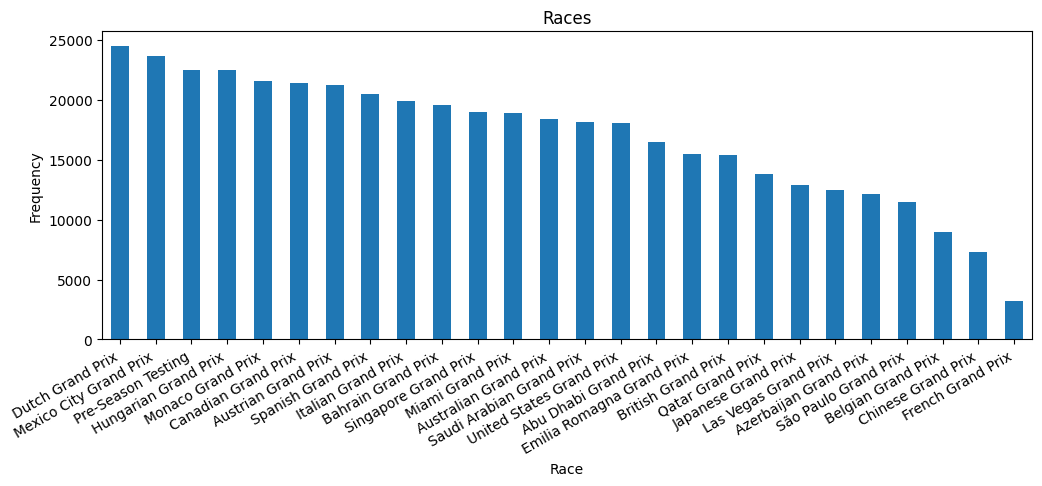

26


In [67]:
# Race 
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
df.race.value_counts().plot(kind='bar', ax=ax)
ax.set_title('Races')
ax.set_xlabel('Race')
ax.set_ylabel('Frequency')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

print(df.race.nunique())

#### NUMERICAL VARIABLES

In [69]:
print(df.select_dtypes(exclude='str').columns.tolist())

['id', 'year', 'pit_stop', 'lap_number', 'stint', 'tyre_life', 'position', 'lap_time_s', 'lap_time_delta', 'cumulative_degradation', 'race_progress', 'position_change', 'pit_next_lap']


In [79]:
# Validate expected ranges for specific numerical variables
checks = {
    "lap_number_positive": (df["lap_number"] > 0).all(),
    "stint_positive": (df["stint"] > 0).all(),
    "tyre_life_non_negative": (df["tyre_life"] >= 0).all(),
    "position_positive": (df["position"] >= 1).all(),
    "lap_time_positive": (df["lap_time_s"] > 0).all(),
    "race_progress_between_0_and_1": df["race_progress"].between(0, 1).all(),
    "position_change_between_neg25_pos25": ((df['position_change'] > -25) & (df['position_change'] < 25)).all(),
    "lap_number_positive": (df["lap_number"] >= 1).all(),
}
checks

{'lap_number_positive': np.True_,
 'stint_positive': np.True_,
 'tyre_life_non_negative': np.True_,
 'position_positive': np.True_,
 'lap_time_positive': np.True_,
 'race_progress_between_0_and_1': np.True_,
 'position_change_between_neg25_pos25': np.True_}

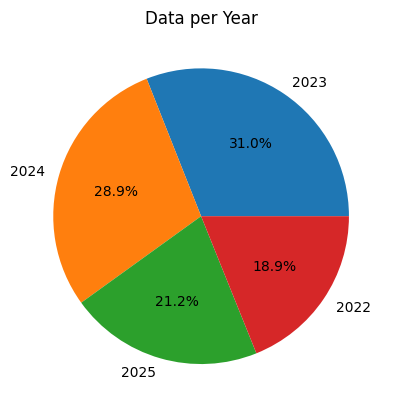

In [72]:
# Year
df.year.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Data per Year')
plt.ylabel('')
plt.show()

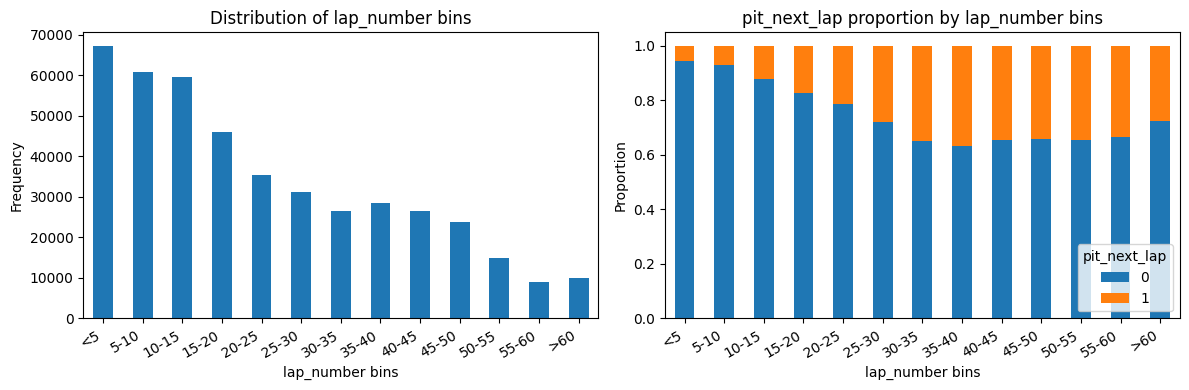

In [78]:
# LapNumber

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# Define LapNumber bins
lap_labels = ['<5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '>60']
df["lap_number_bin"] = pd.cut(
    df.lap_number,
    bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 100],
    labels=lap_labels
)
# -----------------------------
# Plot 1: LapNumber distribution
# -----------------------------
lap_number = df["lap_number_bin"].value_counts(sort=False)
lap_number.plot(kind='bar', ax=ax[0])
ax[0].set_title('Distribution of lap_number bins')
ax[0].set_xlabel('lap_number bins')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha='right')
ax[0].set_ylabel('Frequency')

# ------------------------------------------------
# Plot 2: PitNextLap proportion by LapNumber bins
# ------------------------------------------------
counts = (
    df.groupby(["lap_number_bin", "pit_next_lap"])
    .size()
    .unstack(fill_value=0)
)
# Force x-axis order
counts = counts.reindex(lap_labels)
# Normalize within each LapNumber bin
normalized = counts.div(counts.sum(axis=1), axis=0)
normalized.plot(kind="bar", stacked=True, ax=ax[1])
ax[1].set_title("pit_next_lap proportion by lap_number bins")
ax[1].set_xlabel("lap_number bins")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=30, ha='right')
ax[1].set_ylabel("Proportion")
ax[1].legend(title="pit_next_lap", labels=["0", "1"], loc='lower right')
plt.tight_layout()
plt.show()

# Discard the temporary LapNumberBin column
df.drop(columns=['lap_number_bin'], inplace=True)

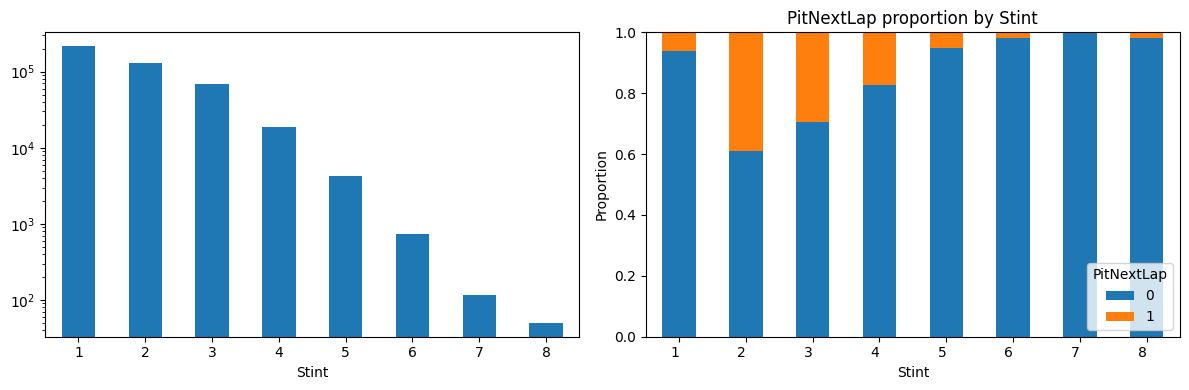

In [16]:
# Stint 
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.Stint.value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
ax[0].set_yscale('log')

counts = (
    df.groupby(["Stint", "PitNextLap"])
    .size()
    .unstack(fill_value=0)
)
# Normalize within each Stint
normalized = counts.div(counts.sum(axis=1), axis=0)
normalized.plot(kind="bar", stacked=True, ax=ax[1])
ax[1].set_title("PitNextLap proportion by Stint")
ax[1].set_xlabel("Stint")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0, ha='right')
ax[1].set_ylabel("Proportion")
ax[1].legend(title="PitNextLap", labels=["0", "1"], loc='lower right')

plt.tight_layout()
plt.show()

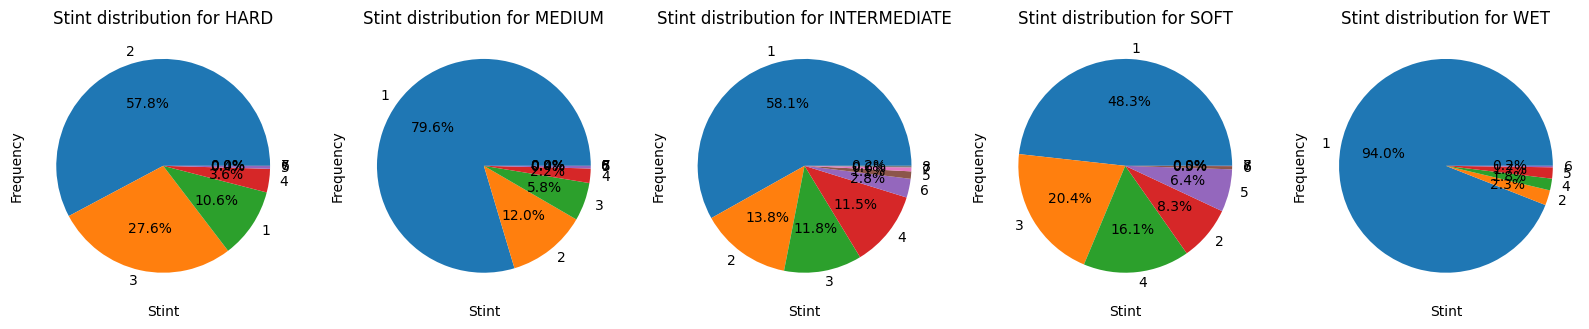

In [81]:
nComp = df.compound.nunique()
fig, ax = plt.subplots(1, nComp, figsize=(4*nComp, 4), sharex=True)

for i, compound in enumerate(df.compound.unique()):
    df[df.compound == compound].stint.value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[i])
    ax[i].set_title(f'Stint distribution for {compound}')
    ax[i].set_xlabel('Stint')
    ax[i].set_ylabel('Frequency')
plt.show()


/var/folders/7m/16c73fl57sd3qqk7qs_575zr0000gn/T/ipykernel_36991/2124891396.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha="right")


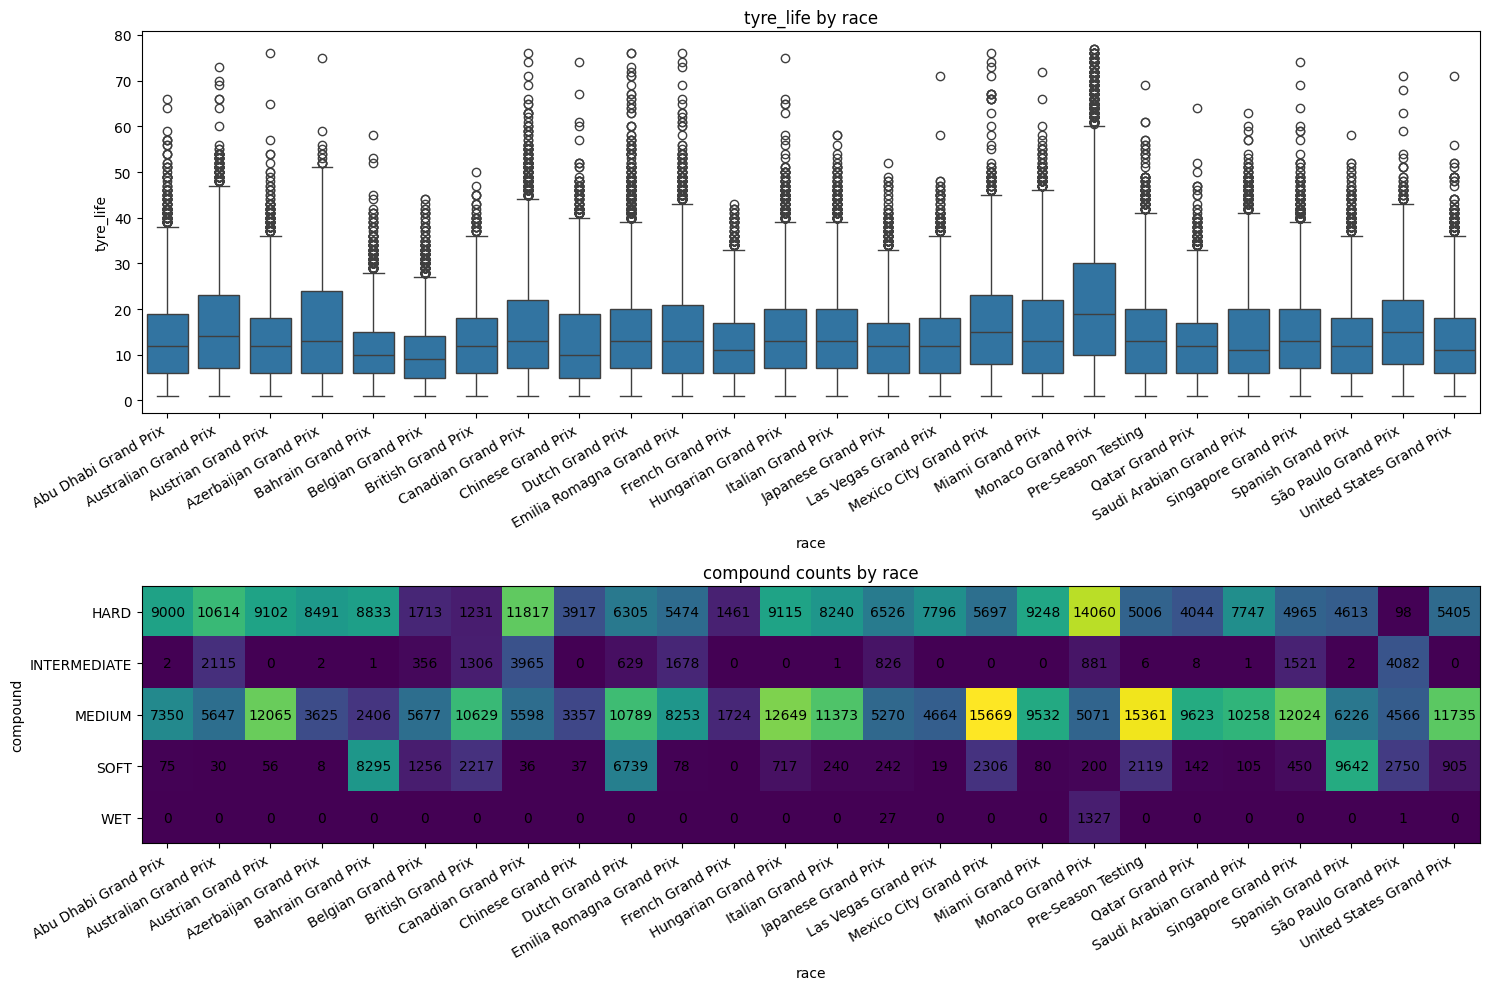

In [82]:
# TyreLife
# Force a consistent Race order
race_order = sorted(df["race"].drop_duplicates().tolist())
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Boxplot ordered by Race
sns.boxplot(
    data=df,
    x="race",
    y="tyre_life",
    order=race_order,
    ax=ax[0]
)
ax[0].set_title("tyre_life by race")
ax[0].set_xlabel("race")
ax[0].set_ylabel("tyre_life")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha="right")


# Plot 2: Compound count matrix ordered by Race
matrix = pd.crosstab(df["compound"], df["race"])
# Reorder matrix columns to match the boxplot Race order
matrix = matrix.reindex(columns=race_order, fill_value=0)
im = ax[1].imshow(matrix)
ax[1].set_xticks(range(len(matrix.columns)))
ax[1].set_yticks(range(len(matrix.index)))
ax[1].set_xticklabels(matrix.columns, rotation=30, ha="right")
ax[1].set_yticklabels(matrix.index)
ax[1].set_xlabel("race")
ax[1].set_ylabel("compound")
ax[1].set_title("compound counts by race")
# Add counts inside cells
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        ax[1].text(
            j,
            i,
            matrix.iloc[i, j],
            ha="center",
            va="center"
        )
plt.tight_layout()
plt.show()

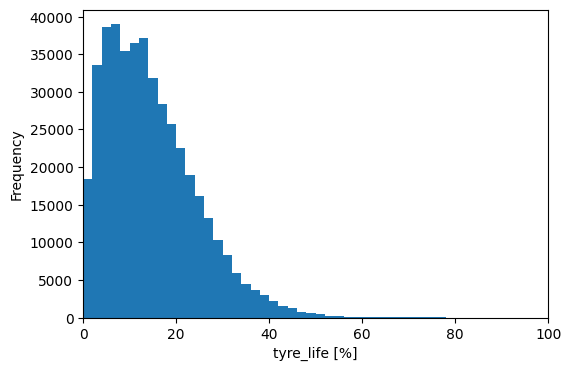

In [119]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df.tyre_life.plot(kind='hist', bins=50, range=(0, 100), ax=ax)
ax.set_xlim(0, 100)
ax.set_xlabel('tyre_life [%]')
plt.show()

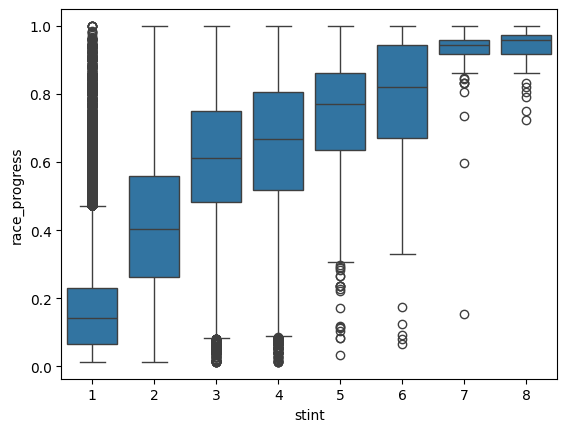

In [83]:
# RaceProgress
sns.boxplot(x='stint', y='race_progress', data=df)
plt.show()

In [97]:
# LapTime (s)
df[df['lap_time_s'] > 2000]

,id,driver,compound,race,year,pit_stop,lap_number,stint,tyre_life,position,lap_time_s,lap_time_delta,cumulative_degradation,race_progress,position_change,pit_next_lap
67979,67979,D047,MEDIUM,Austrian Grand Prix,2023,0,2,1,2.0,1,2473.241,23.820,2377.540,0.028169,0.0,0.0
73750,73750,D150,MEDIUM,Monaco Grand Prix,2025,0,1,1,1.0,3,2473.273,24.272,11.978,0.012821,-2.0,0.0
175487,175487,BRA,MEDIUM,Belgian Grand Prix,2024,0,1,1,1.0,2,2387.902,2423.932,7.824,0.012821,3.0,0.0
183041,183041,FON,HARD,Monaco Grand Prix,2024,1,1,1,1.0,4,2497.268,24.080,2370.062,0.012821,-2.0,0.0
237295,237295,FIS,HARD,Monaco Grand Prix,2024,1,1,1,2.0,13,2497.678,2406.326,2383.678,0.013158,-7.0,0.0
245155,245155,MAL,MEDIUM,Monaco Grand Prix,2024,0,1,1,1.0,8,2502.809,24.926,2385.714,0.012987,1.0,0.0
248029,248029,BUE,HARD,Monaco Grand Prix,2024,0,1,1,1.0,17,2502.648,19.937,2390.333,0.013158,-13.0,0.0
255988,255988,PIQ,HARD,Monaco Grand Prix,2024,0,1,1,1.0,11,2488.609,23.734,2381.300,0.013158,-4.0,0.0
256648,256648,HAR,HARD,Monaco Grand Prix,2024,0,1,1,1.0,7,2488.809,24.926,2383.678,0.012821,-5.0,0.0
262674,262674,D019,MEDIUM,Monaco Grand Prix,2025,0,1,1,2.0,4,2473.461,15.976,24.733,0.012821,0.0,0.0


<Axes: xlabel='compound', ylabel='lap_time_s'>

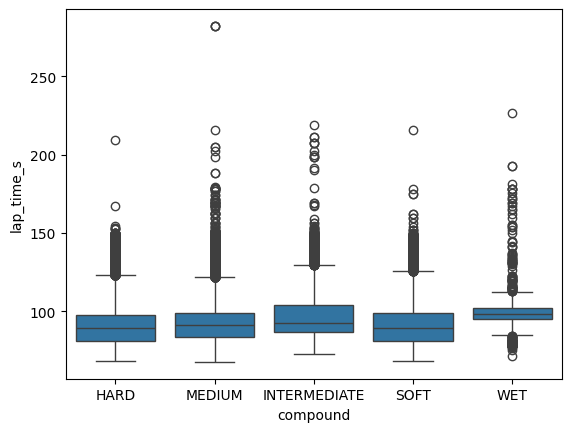

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df[df.lap_time_s < 2000], x='compound', y='lap_time_s', ax=ax[0])
plt.show()

/var/folders/7m/16c73fl57sd3qqk7qs_575zr0000gn/T/ipykernel_36991/2280502378.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha="right")


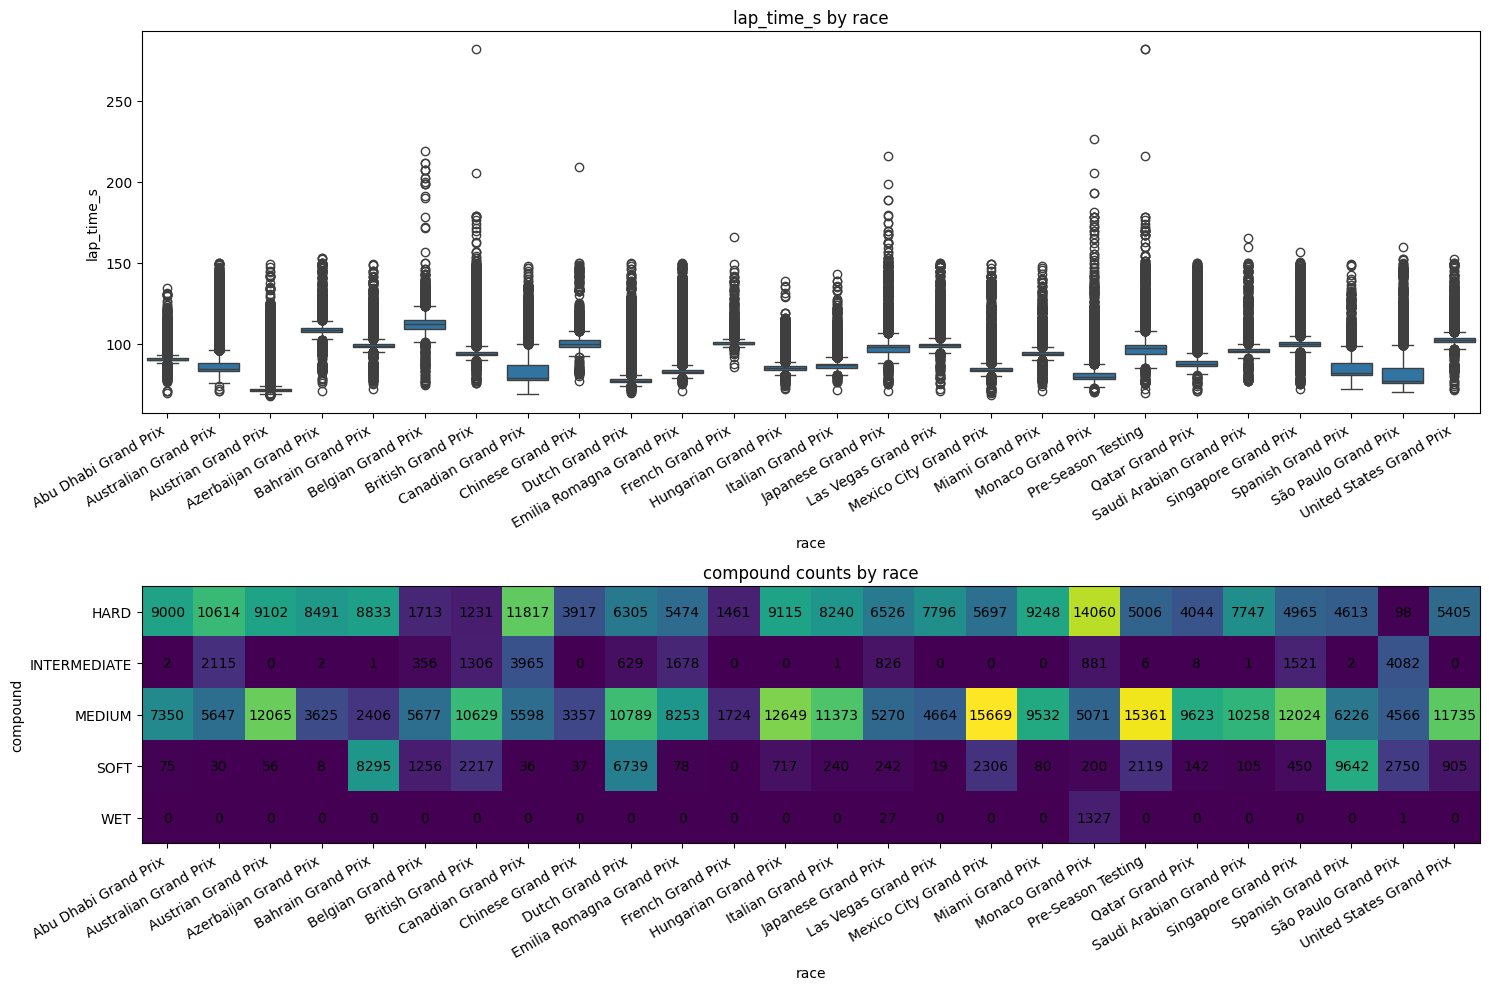

In [91]:
# Force a consistent Race order
race_order = sorted(df["race"].drop_duplicates().tolist())
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Boxplot ordered by Race
sns.boxplot(
    data=df[df.lap_time_s < 2000],
    x="race",
    y="lap_time_s",
    order=race_order,
    ax=ax[0]
)
ax[0].set_title("lap_time_s by race")
ax[0].set_xlabel("race")
ax[0].set_ylabel("lap_time_s")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=30, ha="right")


# Plot 2: Compound count matrix ordered by Race
matrix = pd.crosstab(df["compound"], df["race"])
# Reorder matrix columns to match the boxplot Race order
matrix = matrix.reindex(columns=race_order, fill_value=0)
im = ax[1].imshow(matrix)
ax[1].set_xticks(range(len(matrix.columns)))
ax[1].set_yticks(range(len(matrix.index)))
ax[1].set_xticklabels(matrix.columns, rotation=30, ha="right")
ax[1].set_yticklabels(matrix.index)
ax[1].set_xlabel("race")
ax[1].set_ylabel("compound")
ax[1].set_title("compound counts by race")
# Add counts inside cells
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        ax[1].text(
            j,
            i,
            matrix.iloc[i, j],
            ha="center",
            va="center"
        )
plt.tight_layout()
plt.show()

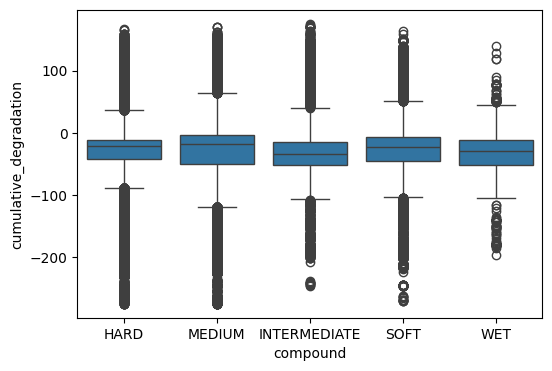

In [ ]:
# CumulativeDegradation
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.boxplot(data=df[df.cumulative_degradation < 2000], x='compound', y='cumulative_degradation', ax=ax)
plt.show()

#### PERFORMANCE INVESTIGATION

In [233]:
def plot_median_iqr(df, x_col, y_col="lap_time_s", xlabel=None, title=None):
    """
    Plot median lap time with 25th-75th percentile error bars.
    """

    data = (
        df.groupby(x_col)[y_col]
        .agg(
            median_lap="median",
            perc_25=lambda x: np.percentile(x, 25),
            perc_75=lambda x: np.percentile(x, 75),
        )
        .reset_index()
    )

    data["lower_error"] = data["median_lap"] - data["perc_25"]
    data["upper_error"] = data["perc_75"] - data["median_lap"]

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.errorbar(
        x=data.index,
        y=data["median_lap"],
        yerr=[data["lower_error"], data["upper_error"]],
        fmt="o",
        capsize=4,
    )

    ax.set_xticks(data.index)
    ax.set_xticklabels(data[x_col], rotation=30, ha='right')

    ax.set_xlabel(xlabel if xlabel else x_col)
    ax.set_ylabel("Median Lap Time [s]")
    ax.set_title(title if title else f"Lap Time vs {x_col}")

    plt.tight_layout()
    plt.show()

    return data

In [237]:
np.arange(0, 105, 5)

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100])

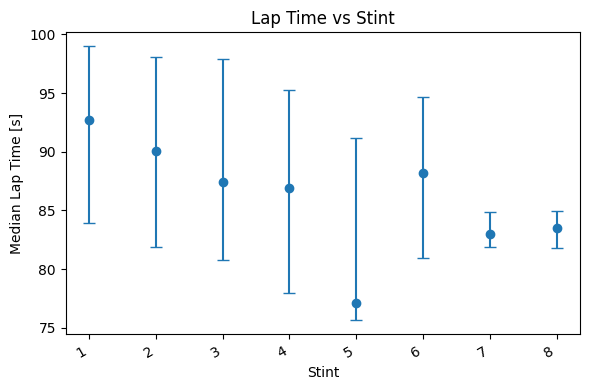

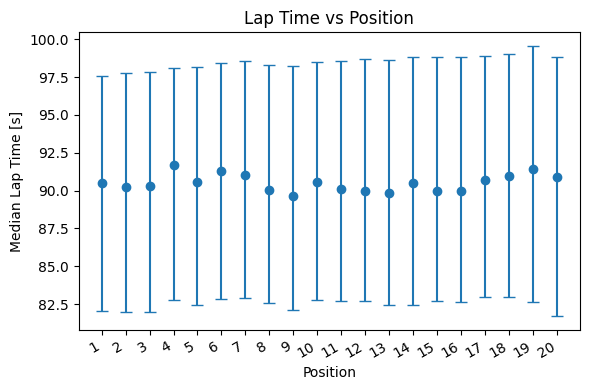

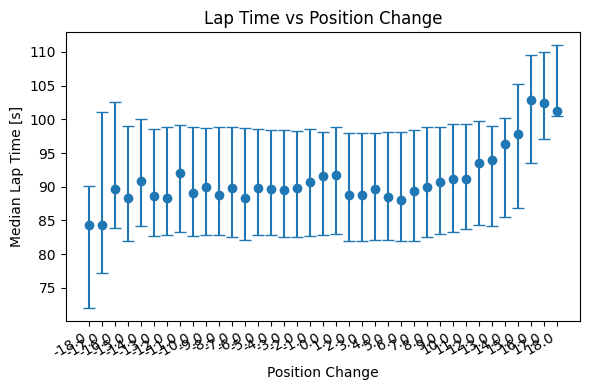

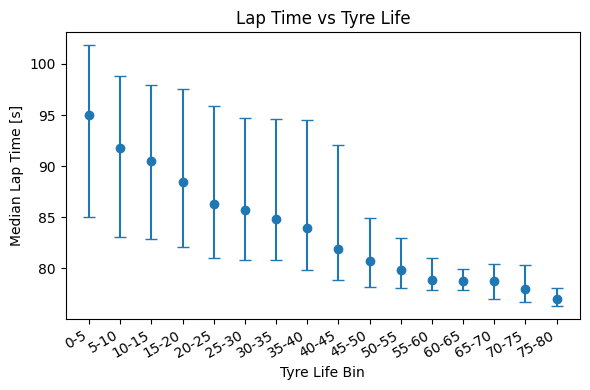

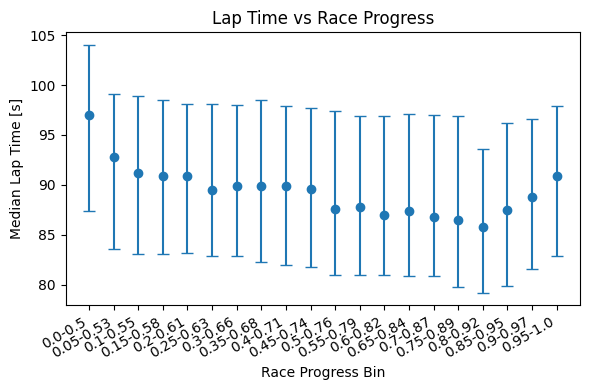

In [243]:
# LapTime vs Stint
stint_data = plot_median_iqr(
    df=df,
    x_col="stint",
    xlabel="Stint",
    title="Lap Time vs Stint",
)

# LapTime vs Position
position_data = plot_median_iqr(
    df=df,
    x_col="position",
    xlabel="Position",
    title="Lap Time vs Position",
)

# LapTime vs PositionChange
position_change_data = plot_median_iqr(
    df=df,
    x_col="position_change",
    xlabel="Position Change",
    title="Lap Time vs Position Change",
)

# LapTime vs TyreLife
df["tyre_life_bin"] = pd.cut(df["tyre_life"], 
                             bins=np.arange(0, 105, 5), 
                             labels=[f'{x}-{y}' for x,y in zip(np.arange(0, 100, 5), np.arange(5, 105, 5))])
tyre_life_data = plot_median_iqr(
    df=df,
    x_col="tyre_life_bin",
    xlabel="Tyre Life Bin",
    title="Lap Time vs Tyre Life",
)

# LapTime vs RaceProgress
df["race_progress_bin"] = pd.cut(df["race_progress"], 
                                 bins=np.linspace(0, 1, 21),
                                 labels=[f'{round(x, 2)}-{round(y, 2)}' for x,y in zip(np.linspace(0, 0.95, 20), np.linspace(0.5, 1, 20))])
race_progress_data = plot_median_iqr(
    df=df,
    x_col="race_progress_bin",
    xlabel="Race Progress Bin",
    title="Lap Time vs Race Progress",
)

/var/folders/7m/16c73fl57sd3qqk7qs_575zr0000gn/T/ipykernel_36991/2002271953.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


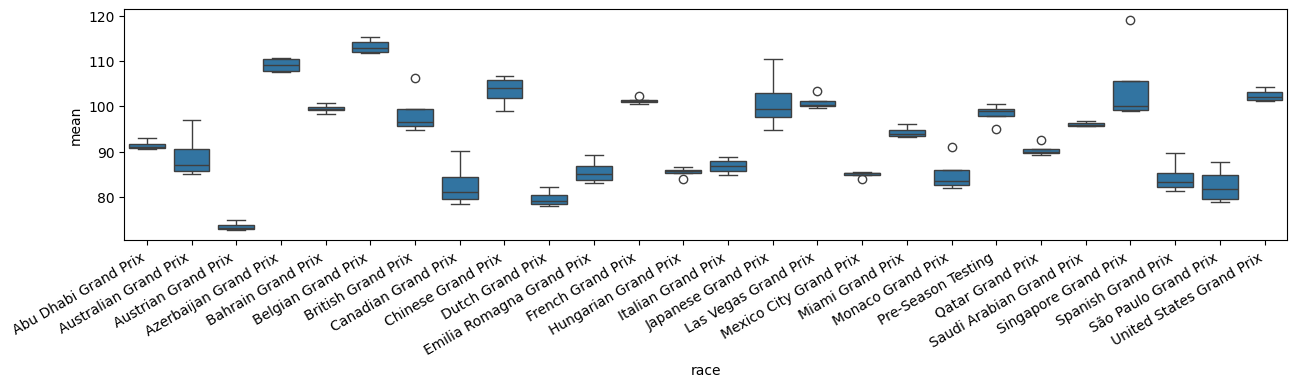

In [245]:
# LapTime per (Race, Year)
lap_race = df.groupby(['race', 'year'])['lap_time_s'].mean().reset_index(name='mean')

fig, ax = plt.subplots(1, 1, figsize=(15, 3))
sns.boxplot(data=lap_race, x='race', y='mean', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

In [258]:
df.columns

Index(['id', 'driver', 'compound', 'race', 'year', 'pit_stop', 'lap_number',
       'stint', 'tyre_life', 'position', 'lap_time_s', 'lap_time_delta',
       'cumulative_degradation', 'race_progress', 'position_change',
       'pit_next_lap', 'tyre_life_bin', 'race_progress_bin'],
      dtype='str')

KeyError: 'race_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrace_progress_binrac

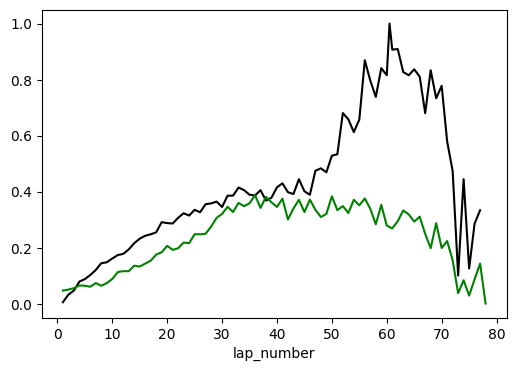

In [260]:
# PitNextLap vs TyreLife
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df.groupby('tyre_life')['pit_next_lap'].mean().plot(color='black', ax=ax)
df.groupby('lap_number')['pit_next_lap'].mean().plot(color='green', ax=ax)
df.groupby('race_progress_bin' * 100)['pit_next_lap'].mean().plot(color='blue', ax=ax)
ax.set_xlim(0, 100)
plt.show()


# PitNextLap vs RaceProgress

# PitNextLap vs Stint

# PitNextLap vs Position

# PitNextLap vs PositionChange


/var/folders/7m/16c73fl57sd3qqk7qs_575zr0000gn/T/ipykernel_36991/2002271953.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


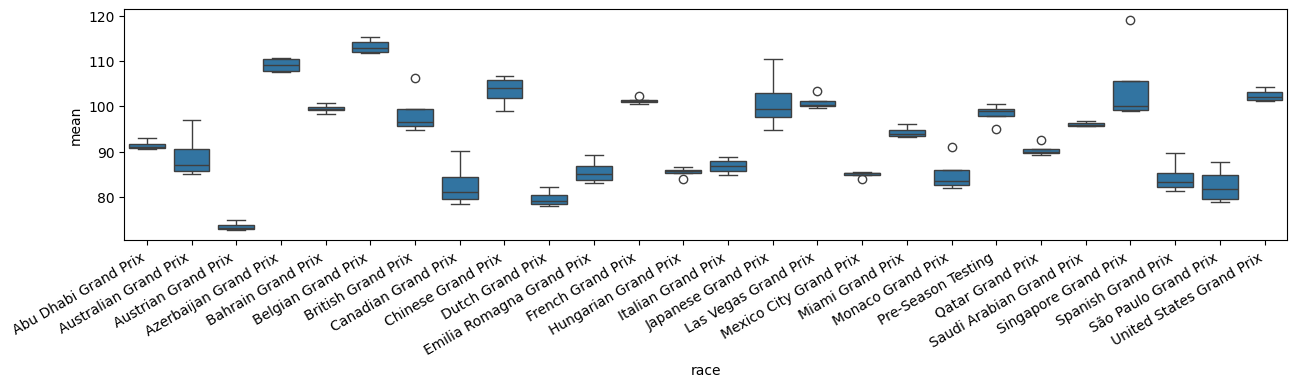

In [ ]:
# LapTime per (Race, Year)
lap_race = df.groupby(['race', 'year'])['lap_time_s'].mean().reset_index(name='mean')

fig, ax = plt.subplots(1, 1, figsize=(15, 3))
sns.boxplot(data=lap_race, x='race', y='mean', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

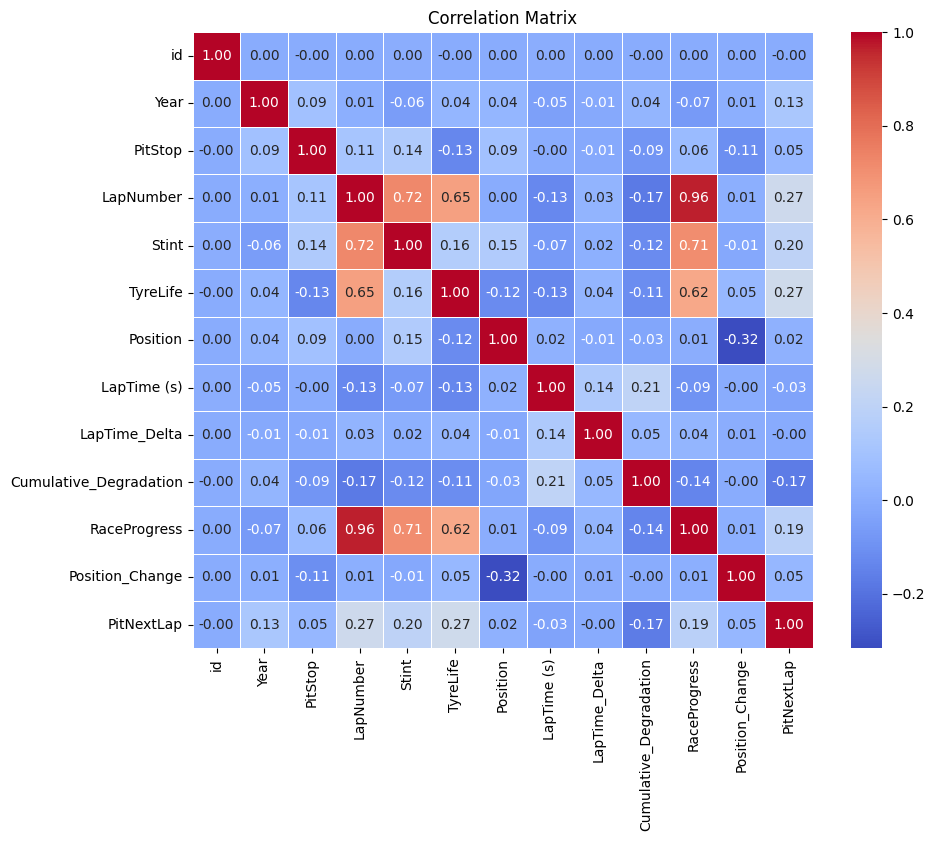

In [21]:
matrix = df[df.select_dtypes(exclude='str').columns.tolist()].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [25]:
df_test = pd.read_csv('./data/predicting_f1_pit_stops/test.csv')
df_test.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


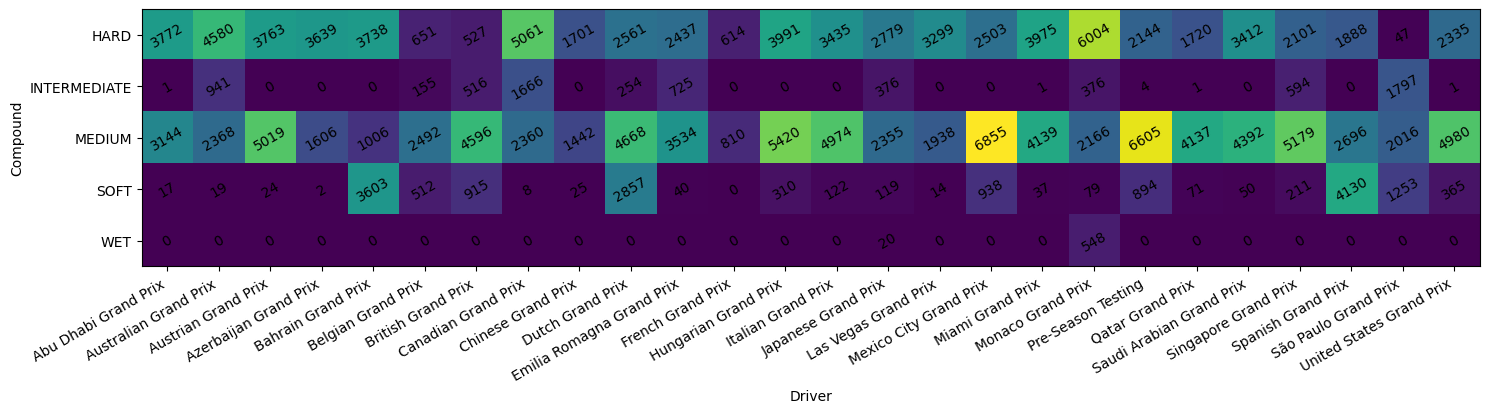

In [26]:
matrix = pd.crosstab(df_test["Compound"], df_test["Race"])

fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(matrix)
ax.set_xticks(range(len(matrix.columns)))
ax.set_yticks(range(len(matrix.index)))
ax.set_xticklabels(matrix.columns, ha='right', rotation=30)
ax.set_yticklabels(matrix.index)
ax.set_xlabel("Driver")
ax.set_ylabel("Compound")

# Add counts inside cells
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        ax.text(j, i, matrix.iloc[i, j], ha="center", va="center", rotation=30)

#plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()